### Import Packages

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from scipy.interpolate import griddata
import tensorflow as tf
from keras.models import load_model

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

print("TensorFlow version: ", tf.__version__)
print("Number of GPUs available: ", len(tf.config.list_physical_devices('GPU')))

wind_MLP = load_model('wind_MLP.keras')

TensorFlow version:  2.19.0
Number of GPUs available:  1


### Data Preprocessing

In [4]:
cols = ['u','u_e','u_n']
scaled_cols = ['scaled_' + col for col in cols]

# Load datasets
df_buoy = pd.read_csv('WLIS_data.csv')
df_buoy = df_buoy.rename(columns={'WSPD':'u'})
df_buoy['TmStamp'] = pd.to_datetime(df_buoy['TmStamp'], format='mixed')
df_buoy.set_index('TmStamp', inplace=True)

df_stn = pd.read_csv('Sikorsky_data.csv')
df_stn = df_stn.rename(columns={'WSPD':'u'})
df_stn['TmStamp'] = pd.to_datetime(df_stn['TmStamp'], format='mixed')
df_stn.set_index('TmStamp', inplace=True)

# Add east and north components
alpha = -13
df_buoy['rad'] = np.pi/180 * ((alpha + 630 - df_buoy['WDIR']) % 360)
df_buoy['u_e'] = df_buoy['u'] * np.cos(df_buoy['rad'])
df_buoy['u_n'] = df_buoy['u'] * np.sin(df_buoy['rad'])

df_stn['rad'] = np.pi/180 * ((alpha + 630 - df_stn['WDIR']) % 360)
df_stn['u_e'] = df_stn['u'] * np.cos(df_stn['rad'])
df_stn['u_n'] = df_stn['u'] * np.sin(df_stn['rad'])

# Transform station wind into buoy wind
def wind_transform(df_stn):
    wind_T_uc = wind_MLP.predict(df_stn[cols[1:]], verbose=0)
    u_e, u_n = wind_T_uc[:, 0], wind_T_uc[:, 1]
    wind_T_u = np.sqrt(u_e**2 + u_n**2)
    return pd.DataFrame({'u': wind_T_u, 'u_e': u_e, 'u_n': u_n}, index=df_stn.index)

df_T = wind_transform(df_stn)

# df_test: [2024-07-01 00:00:00 ~ 2025-06-30 23:00:00]
split = pd.to_datetime('2024-06-30 23:59:00')
df_buoy_train = df_buoy[df_buoy.index < split]
df_buoy_test = df_buoy[df_buoy.index > split]
df_stn_train = df_stn[df_stn.index < split]
df_stn_test = df_stn[df_stn.index > split]
df_T_train = df_T[df_T.index < split]
df_T_test = df_T[df_T.index > split]

# Data normalization
scaled_wave, scaled_wind, scaled_T = MinMaxScaler(), MinMaxScaler(), MinMaxScaler()

df_buoy_train, df_buoy_test = df_buoy_train.copy(), df_buoy_test.copy()
df_buoy_train.loc[:, 'scaled_H'] = scaled_wave.fit_transform(df_buoy_train[['H']])
df_buoy_test.loc[:, 'scaled_H'] = scaled_wave.transform(df_buoy_test[['H']])
df_buoy_train.loc[:, scaled_cols] = scaled_wind.fit_transform(df_buoy_train[cols])
df_buoy_test.loc[:, scaled_cols] = scaled_wind.transform(df_buoy_test[cols])

df_T_train, df_T_test = df_T_train.copy(), df_T_test.copy()
df_T_train.loc[:, scaled_cols] = scaled_T.fit_transform(df_T_train[cols])
df_T_test.loc[:, scaled_cols] = scaled_T.transform(df_T_test[cols])

### Data Preparation: Train-Test-Validation Split

In [5]:
step, output = 24, 12
features = ['scaled_H'] + scaled_cols

def create_sequences(df_buoy, df_T, step, output):
    X, y = [], []
    periods = step + output
    for i in range(len(df_buoy) - periods + 1):
        window = df_buoy.iloc[i:(i+periods)]
        expect = pd.date_range(start=window.index[0], periods=periods, freq='h')
        if not window.index.equals(expect):
            continue
        X_seq = window.values.copy()
        X_seq[step:, 0] = -1
        X_seq[step:, 1:] = df_T.iloc[(i+step):(i+periods)].values
        X.append(X_seq)
        y.append(window.iloc[step:, 0].values)
    return np.array(X), np.array(y)

X_test, y_test = create_sequences(df_buoy_test[features], df_T_test[scaled_cols], step, output)
print(X_test.shape, y_test.shape)

(8725, 36, 4) (8725, 12)


### Model Evaluation

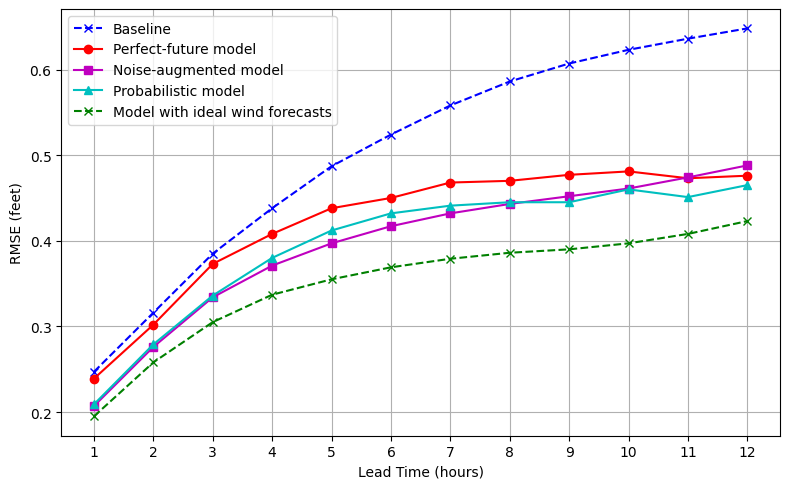

In [6]:
lead_time = list(range(1, 13))
rmse_base = [0.247, 0.316, 0.385, 0.438, 0.487, 0.524, 0.558, 0.586, 0.607, 0.623, 0.636, 0.648]
rmse_fcst = [0.239, 0.302, 0.373, 0.408, 0.438, 0.450, 0.468, 0.470, 0.477, 0.481, 0.473, 0.476]
rmse_aug = [0.207, 0.276, 0.334, 0.371, 0.397, 0.417, 0.432, 0.443, 0.452, 0.461, 0.474, 0.488]
rmse_aug_CI = [0.209, 0.279, 0.336, 0.380, 0.412, 0.432, 0.441, 0.445, 0.445, 0.460, 0.451, 0.465]
rmse_ideal = [0.195, 0.258, 0.305, 0.337, 0.355, 0.369, 0.379, 0.386, 0.390, 0.397, 0.408, 0.423]

plt.figure(figsize=(8, 5))
plt.plot(lead_time, rmse_base, color='b', linestyle='--', marker='x', label='Baseline')
plt.plot(lead_time, rmse_fcst, color='r', marker='o', label='Perfect-future model')
plt.plot(lead_time, rmse_aug, color='m', marker='s', label='Noise-augmented model')
plt.plot(lead_time, rmse_aug_CI, color='c', marker='^', label='Probabilistic model')
plt.plot(lead_time, rmse_ideal, color='g', linestyle='--', marker='x', label='Model with ideal wind forecasts')

plt.legend()
plt.xticks(lead_time)
plt.xlabel('Lead Time (hours)')
plt.ylabel('RMSE (feet)')
plt.grid(True)
plt.tight_layout()
# plt.savefig('summary.png', dpi=1200, format='png')
plt.show()

In [7]:
rho = 0.054
abs_res, rel_res = 0.2, 0.05
y_true = scaled_wave.inverse_transform(y_test)

# Add future wind noise
def add_noise(df, abs_std, rel_std, random_seed=42):
    rng = np.random.default_rng(random_seed)
    wind = df[cols].to_numpy(dtype=float)
    stds = abs_std + rel_std * wind[:, 0]
    cov = np.array([[1, rho], [rho, 1]])
    L_cov = np.linalg.cholesky(cov)
    z = rng.normal(0, 1, size=(wind.shape[0], 2))
    noise = z @ L_cov.T * stds[:, None]
    nu_e = wind[:, 1] + noise[:, 0]
    nu_n = wind[:, 2] + noise[:, 1]
    nu = np.linalg.norm(np.column_stack([nu_e, nu_n]), axis=1)
    nu = np.maximum(nu, 0.25)
    return pd.DataFrame({'u':nu, 'u_e':nu_e, 'u_n':nu_n}, index=df.index)

# Define noise levels
def noise_level(model):
    abs_levels = np.arange(0.0, 3.0 + 0.001, abs_res)
    rel_levels = np.arange(0.0, 1.0 + 0.001, rel_res)
    rmse_arr_lst = []
    for abs_std in abs_levels:
        for rel_std in rel_levels:
            df_stn_test_nu = add_noise(df_stn_test[cols], abs_std, rel_std)
            df_stn_test_nu_T = wind_transform(df_stn_test_nu)
            df_stn_test_nu_T.loc[:, scaled_cols] = scaled_T.transform(df_stn_test_nu_T[cols])
            X_nu = create_sequences(df_buoy_test[features], df_stn_test_nu_T[scaled_cols], step, output)[0]
            y_pred = model.predict(X_nu, verbose=0)
            y_pred_raw = scaled_wave.inverse_transform(y_pred)
            rmse_arr = np.sqrt(mean_squared_error(y_true, y_pred_raw, multioutput='raw_values'))
            rmse_arr_lst.append((abs_std, rel_std, rmse_arr))
    return rmse_arr_lst

# Calculate the area of the surface below the baseline plane in the xy-plane projection
def area_below_baseline(rmse_arr_lst, rmse_base):
    abs_vals = np.array([item[0] for item in rmse_arr_lst])
    rel_vals = np.array([item[1]*100 for item in rmse_arr_lst])
    rmse_vals = np.array([item[2] for item in rmse_arr_lst])
    grid_x, grid_y = np.meshgrid(np.unique(abs_vals), np.unique(rel_vals))
    areas = []
    for t in range(len(rmse_base)):
        grid_z = griddata((abs_vals, rel_vals), rmse_vals[:, t], (grid_x, grid_y), method='linear')
        areas.append(np.sum(grid_z < rmse_base[t]) * abs_res*rel_res*100)
    return areas

In [8]:
model_fcst = load_model('model_fcst.keras')
fcst_areas = area_below_baseline(noise_level(model_fcst), rmse_base)
print('Area below baseline:', ', '.join([f'{area:.1f}' for area in fcst_areas]))

Area below baseline: 79.0, 120.0, 120.0, 145.0, 160.0, 178.0, 186.0, 196.0, 193.0, 207.0, 200.0, 187.0


In [9]:
model_aug = load_model('model_aug.keras')
aug_areas = area_below_baseline(noise_level(model_aug), rmse_base)
print('Area below baseline:', ', '.join([f'{area:.1f}' for area in aug_areas]))

Area below baseline: 244.0, 197.0, 171.0, 168.0, 173.0, 180.0, 180.0, 186.0, 190.0, 191.0, 193.0, 192.0
